In [ ]:
import pandas as pd
import numpy as np

pd.set_option('display.max_rows', 125)

df = pd.read_csv('data4.csv')  # Assuming no header in the CSV
df.columns = ['index', 'start', 'end', 'key', 'region'] # Assigning column names



# Function to convert hex string to integer, handling potential non-hex values
def hex_to_int(val):
    if isinstance(val, str):
        try:
            return int(val, 16)
        except ValueError:
            return None # Or handle as appropriate, e.g., keep original or NaN
    elif pd.isna(val):
        return None # Explicitly handle NaN values
    elif isinstance(val, (int, float)): # If it's already a number
        if val == int(val): # Check if it's an integer value (e.g., 1.0)
            return int(val)
        else:
            return None # Or keep as is, depending on desired handling of non-integer floats
    return None # Fallback for unexpected types

# Convert 'start', 'end', and 'key' columns to integers and ensure they are stored as object dtype
# to prevent overflow with very large numbers
df['start'] = df['start'].apply(hex_to_int).astype(object)
df['end'] = df['end'].apply(hex_to_int).astype(object)
df['key'] = df['key'].apply(hex_to_int).astype(object)

df

,index,start,end,key,region
0,1,1,1,1,100.00
1,2,2,3,3,50.00
2,3,4,7,7,75.00
3,4,8,15,8,0.00
4,5,16,31,21,31.25
5,6,32,63,49,53.13
6,7,64,127,76,18.75
7,8,128,255,224,75.00
8,9,256,511,467,82.42
9,10,512,1023,514,0.39


Region Category Frequencies:
region
0-5       3
6-10      3
11-15     3
16-20     4
21-25     3
26-30     4
31-35     5
36-40     5
41-45     4
46-50     7
51-55     4
56-60     1
61-65     6
66-70     8
71-75     5
76-80     3
81-85     5
86-90     1
91-95     3
96-100    5
Name: count, dtype: int64

Total values categorized: 82


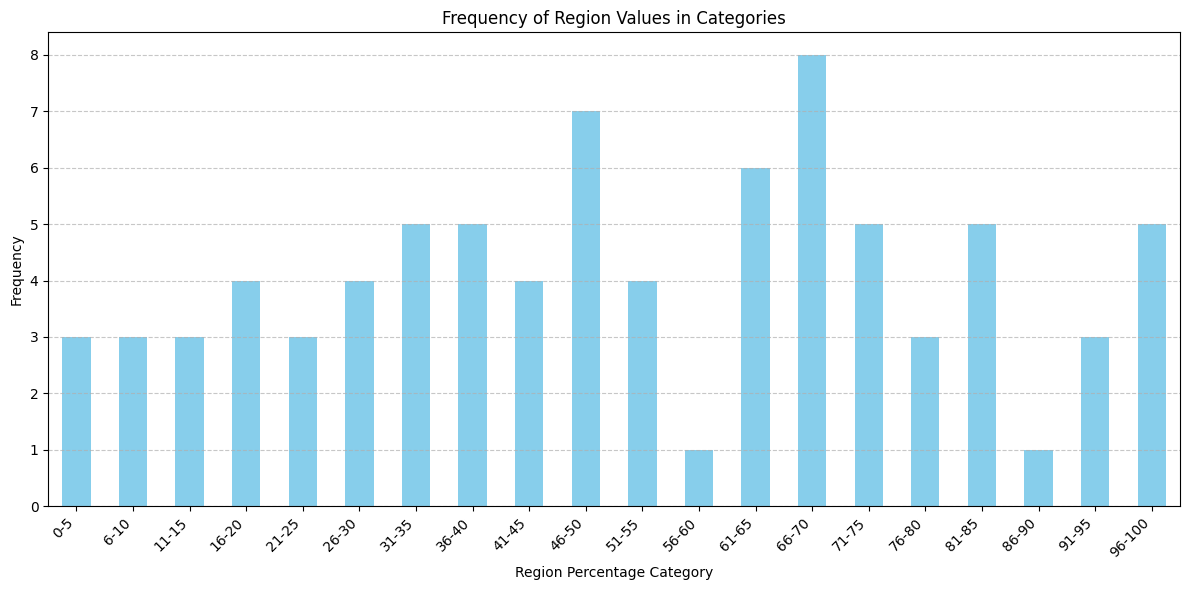

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Define the bins for the categories (0 to 100)
bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
labels = ['0-5', '6-10', '11-15', '16-20', '21-25', '26-30', '31-35', '36-40', '41-45', '46-50', '51-55', '56-60', '61-65', '66-70', '71-75', '76-80', '81-85', '86-90', '91-95', '96-100',]

# Categorize the 'region' values into the defined bins
# Drop NaN values before categorization to avoid them appearing as a separate category
# `right=True` means intervals are (lower, upper], `include_lowest=True` ensures 0 is included in the first bin.
df_region_cleaned = df['region'].dropna()
category_counts = pd.cut(df_region_cleaned, bins=bins, labels=labels, right=True, include_lowest=True).value_counts().sort_index()

# Print the frequencies
print("Region Category Frequencies:")
print(category_counts)
print(f"\nTotal values categorized: {category_counts.sum()}")

# Create and display the bar graph
plt.figure(figsize=(12, 6))
category_counts.plot(kind='bar', color='skyblue')
plt.title('Frequency of Region Values in Categories')
plt.xlabel('Region Percentage Category')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Region Category Frequencies:
region
0-2.5        3
2.6-5        0
5.1-7.5      1
7.6-10       2
10.1-12.5    1
12.6-15      2
15.1-17.5    1
17.6-20      3
20.1-22.5    0
22.6-25      3
25.1-27.5    2
27.6-30      2
30.1-32.5    3
32.6-35      2
35.1-37.5    3
37.6-40      2
40.1-42.5    1
42.6-45      3
45.1-47.5    4
47.6-50      3
50.1-52.5    3
52.6-55      1
55.1-57.5    1
57.6-60      0
60.1-62.5    1
62.6-65      5
65.1-67.5    4
67.6-70      4
70.1-72.5    2
72.6-75      3
75.1-77.5    2
77.6-80      1
80.1-82.5    2
82.6-85      3
85.1-87.5    1
87.6-90      0
90.1-92.5    2
92.6-95      1
95.1-97.5    3
97.6-100     2
Name: count, dtype: int64

Total values categorized: 82


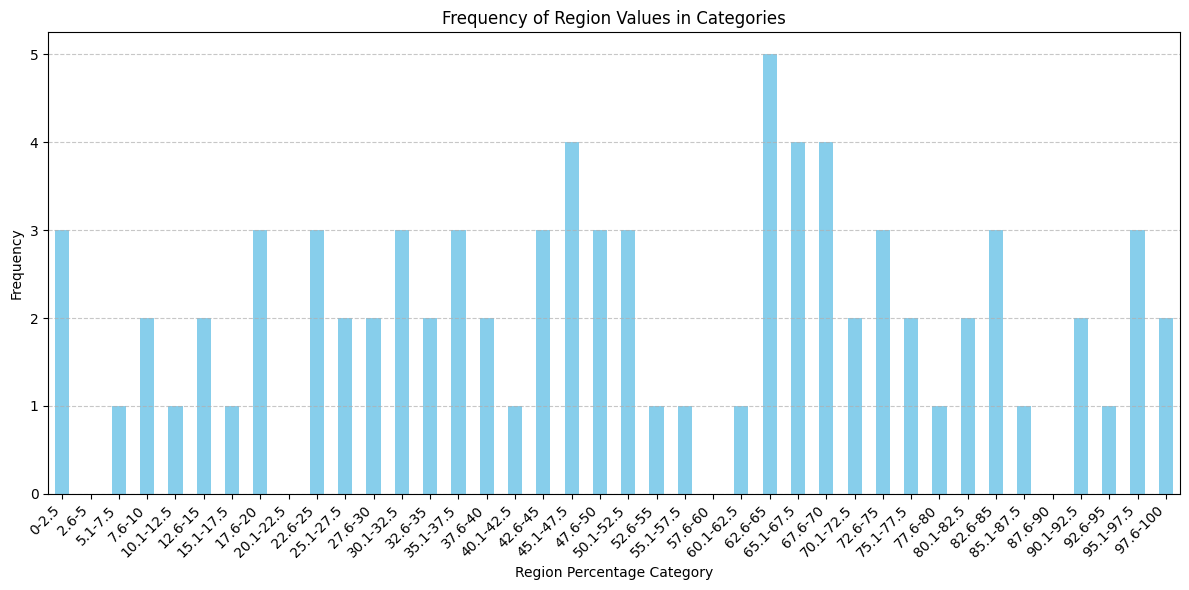

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Define the bins for the categories (0 to 100)
bins = [
    0, 2.5, 5, 7.5, 10, 12.5, 15, 17.5, 20, 22.5, 25, 27.5, 30, 32.5, 35, 37.5, 40,
    42.5, 45, 47.5, 50, 52.5, 55, 57.5, 60, 62.5, 65, 67.5, 70, 72.5, 75, 77.5, 80,
    82.5, 85, 87.5, 90, 92.5, 95, 97.5, 100
]

labels = [
    '0-2.5', '2.6-5', '5.1-7.5', '7.6-10', '10.1-12.5', '12.6-15', '15.1-17.5', '17.6-20',
    '20.1-22.5', '22.6-25', '25.1-27.5', '27.6-30', '30.1-32.5', '32.6-35', '35.1-37.5', '37.6-40',
    '40.1-42.5', '42.6-45', '45.1-47.5', '47.6-50', '50.1-52.5', '52.6-55', '55.1-57.5', '57.6-60',
    '60.1-62.5', '62.6-65', '65.1-67.5', '67.6-70', '70.1-72.5', '72.6-75', '75.1-77.5', '77.6-80',
    '80.1-82.5', '82.6-85', '85.1-87.5', '87.6-90', '90.1-92.5', '92.6-95', '95.1-97.5', '97.6-100'
]
# Categorize the 'region' values into the defined bins
# Drop NaN values before categorization to avoid them appearing as a separate category
# `right=True` means intervals are (lower, upper], `include_lowest=True` ensures 0 is included in the first bin.
df_region_cleaned = df['region'].dropna()
category_counts = pd.cut(df_region_cleaned, bins=bins, labels=labels, right=True, include_lowest=True).value_counts().sort_index()

# Print the frequencies
print("Region Category Frequencies:")
print(category_counts)
print(f"\nTotal values categorized: {category_counts.sum()}")

# Create and display the bar graph
plt.figure(figsize=(12, 6))
category_counts.plot(kind='bar', color='skyblue')
plt.title('Frequency of Region Values in Categories')
plt.xlabel('Region Percentage Category')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

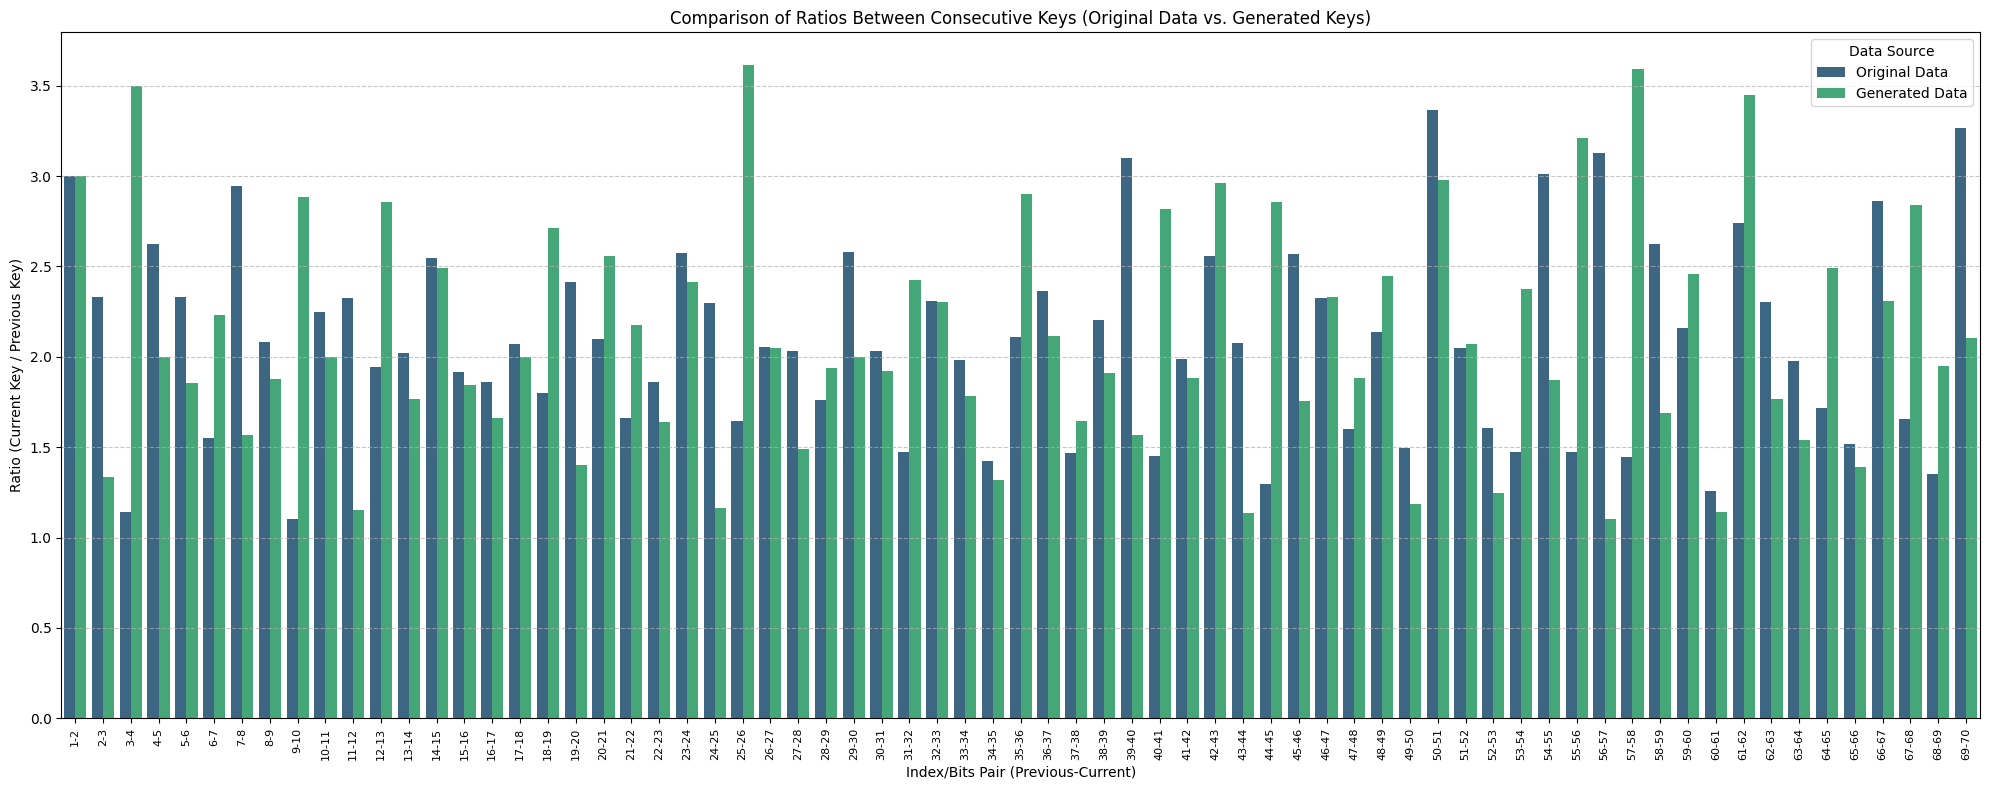

In [ ]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for grouped bar plots
from decimal import Decimal, getcontext

def generate_private_key(bits: int, rng: random.Random) -> int:
    """
    Generate a deterministic private key in the range:
    [2^(bits-1), 2^bits - 1]
    """
    low = 1 << (bits - 1)
    range_size = 1 << bits  # size = 2^bits

    # Generate enough random bits
    k = rng.getrandbits(bits)

    # Reduce into range and shift if needed
    k %= range_size
    if k < low:
        k += low

    return k

def main():
    # Single deterministic seed (MT19937)
    MASTER_SEED = 100000000000
    rng = random.Random(MASTER_SEED)

    generated_keys_list = []
    for bits in range(1, 161): # Iterate for all possible bits values
        k = generate_private_key(bits, rng)
        generated_keys_list.append({'bits': bits, 'key': k})

    return pd.DataFrame(generated_keys_list)

if __name__ == "__main__":
    generated_df = main()


    # Filter data for keys up to bits = 70 (DataFrame index up to 69)
    df_to_analyze_ratios = generated_df[generated_df['bits'] <= 70].copy()

    ratios_data_generated = []
    getcontext().prec = 100 # Set high precision for Decimal operations

    # Calculate ratios between consecutive generated keys
    for i in range(1, len(df_to_analyze_ratios)): # i goes from 1 to 69
        key_current_dec = Decimal(str(df_to_analyze_ratios.loc[i, 'key']))
        key_previous_dec = Decimal(str(df_to_analyze_ratios.loc[i-1, 'key']))

        if key_previous_dec != 0:
            ratio = key_current_dec / key_previous_dec
            ratios_data_generated.append({
                'pair_label': f"{df_to_analyze_ratios.loc[i-1, 'bits']}-{df_to_analyze_ratios.loc[i, 'bits']}",
                'ratio': float(ratio)
            })

    df_ratios_generated = pd.DataFrame(ratios_data_generated)


    # --- Start of fix ---
    # Calculate ratios for the original data (df)
    # Assuming 'df' DataFrame is available from previous cells and properly processed
    df_to_analyze_ratios_original = df.loc[0:69, 'key'].reset_index(drop=True) # Get the first 70 keys, reset index for 0-based access

    ratios_data_original = []
    # Loop from 1 to 69 (inclusive) to get pairs (0,1), (1,2) ... (68,69)
    # The pair_label should be based on the original index + 1
    # So, for pair (0,1), it should be "1-2"
    for i in range(1, len(df_to_analyze_ratios_original)):
        key_current_dec_orig = Decimal(str(df_to_analyze_ratios_original.loc[i]))
        key_previous_dec_orig = Decimal(str(df_to_analyze_ratios_original.loc[i-1]))

        if key_previous_dec_orig != 0:
            ratio_orig = key_current_dec_orig / key_previous_dec_orig
            ratios_data_original.append({
                'pair_label': f"{i}-{i+1}", # index + 1 for bits representation
                'ratio': float(ratio_orig)
            })

    df_ratios_original = pd.DataFrame(ratios_data_original)
    # --- End of fix ---

    # Retrieve ratios from the original df (from NQozN11ld6Po's sorted_ratios_df)
    # Assuming sorted_ratios_df is available in the global scope from NQozN11ld6Po execution
    # df_ratios_original = sorted_ratios_df.copy() # This line is now replaced by the above calculation
    # df_ratios_original.rename(columns={'index_pair': 'pair_label'}, inplace=True) # No need to rename if created with 'pair_label'



    # Filter both dataframes to a common range of pairs (e.g., "1-2" to "69-70")
    # df_ratios_original has "0-1", "1-2", ..., "69-70"
    # df_ratios_generated has "1-2", "2-3", ..., "69-70"
    # Let's align on "1-2" to "69-70" for consistent comparison
    common_pairs = df_ratios_generated['pair_label'].tolist()

    df_ratios_original_filtered = df_ratios_original[df_ratios_original['pair_label'].isin(common_pairs)].reset_index(drop=True)

    # Add a 'source' column to each DataFrame for differentiation in plotting
    df_ratios_original_filtered['source'] = 'Original Data'
    df_ratios_generated['source'] = 'Generated Data'

    # Concatenate the two DataFrames and reset the index to prevent duplicate labels
    combined_ratios_df = pd.concat([df_ratios_original_filtered, df_ratios_generated]).reset_index(drop=True)

    # Create a grouped bar graph
    plt.figure(figsize=(20, 8))
    sns.barplot(x='pair_label', y='ratio', hue='source', data=combined_ratios_df, palette='viridis')
    plt.xlabel('Index/Bits Pair (Previous-Current)')
    plt.ylabel('Ratio (Current Key / Previous Key)')
    plt.title('Comparison of Ratios Between Consecutive Keys (Original Data vs. Generated Keys)')
    plt.xticks(rotation=90, fontsize=8) # Rotate labels for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='Data Source')
    plt.tight_layout()
    plt.show()